In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [27]:
uploads = files.upload()

Saving severance.jfif to severance (1).jfif


In [28]:
img = cv2.imread('severance.jfif')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img__hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb

array([[[  6,   5,   0],
        [  4,   3,   0],
        [  2,   2,   0],
        ...,
        [  1,   1,   0],
        [  4,   1,   0],
        [  5,   2,   0]],

       [[  6,   6,   8],
        [  4,   4,   4],
        [  2,   2,   2],
        ...,
        [  1,   1,   0],
        [  5,   5,   3],
        [  9,   9,   7]],

       [[  0,   0,  14],
        [  0,   0,  12],
        [  0,   0,  11],
        ...,
        [  5,   9,  20],
        [  1,   5,  16],
        [  0,   0,  11]],

       ...,

       [[  6,   6,   8],
        [  0,   0,   2],
        [  0,   0,   2],
        ...,
        [206, 210, 175],
        [195, 197, 160],
        [174, 179, 139]],

       [[  6,   4,   5],
        [  4,   2,   3],
        [  2,   0,   1],
        ...,
        [134, 138, 115],
        [176, 179, 152],
        [206, 211, 181]],

       [[  6,   4,   5],
        [  4,   2,   3],
        [  2,   0,   1],
        ...,
        [ 12,  15,   0],
        [ 55,  58,  37],
        [130, 134, 111]]

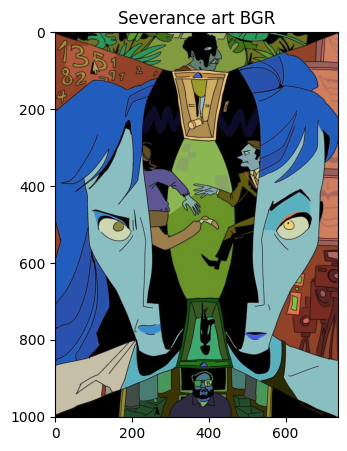

In [32]:
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title('Severance art BGR')
plt.show()


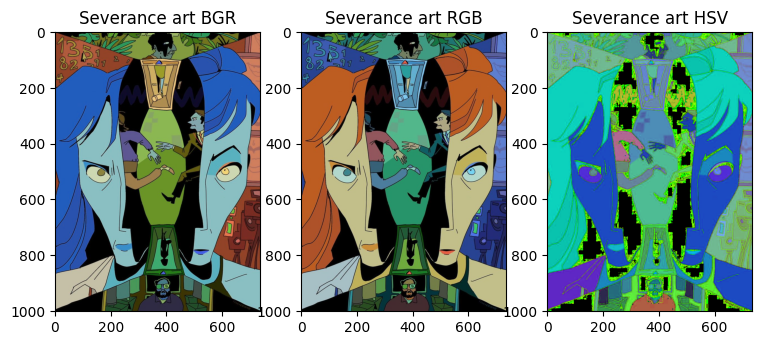

In [33]:
fig, ax = plt.subplots(1,3,figsize=(9,5))
ax[0].imshow(img)
ax[0].set_title('Severance art BGR')

ax[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[1].set_title('Severance art RGB')

ax[2].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV))
ax[2].set_title('Severance art HSV')

plt.show()

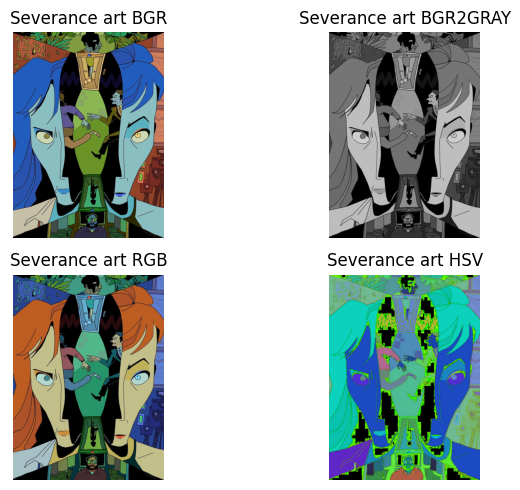

In [36]:
fig, ax = plt.subplots(2,2,figsize=(8,5))

ax[0,0].imshow(img)
ax[0,0].set_title('Severance art BGR')
ax[0,0].axis('off')

ax[0,1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), cmap= 'gray')
ax[0,1].set_title('Severance art BGR2GRAY')
ax[0,1].axis('off')

ax[1,0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[1,0].set_title('Severance art RGB')
ax[1,0].axis('off')

ax[1,1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV))
ax[1,1].set_title('Severance art HSV')
ax[1,1].axis('off')

plt.tight_layout()
plt.savefig('conversao_cores.jpg')

plt.show()

### Exercício: Quantização de Imagens

Vamos quantizar a imagem em tons de cinza para diferentes níveis de intensidade.

OBS: basicamente eu passo como parametro o img_gray_2d e os bits  

In [57]:
def quantizar_imagem(imagem, bits):
  val_max = 255
  num_niveis = 2**bits

  passo_nivel = val_max / (num_niveis - 1)

  imagem_quantizada = np.round(imagem / val_max * (num_niveis - 1))

  imagem_quantizada = imagem_quantizada * passo_nivel

  return imagem_quantizada.astype(np.uint8)

In [58]:
img_gray_2d = img_gray.squeeze()
img_gray_2d = img_gray

In [59]:
img_1bit = quantizar_imagem(img_gray_2d, 1)
img_2bit = quantizar_imagem(img_gray_2d, 2)
img_4bit = quantizar_imagem(img_gray_2d, 4)
img_8bit = quantizar_imagem(img_gray_2d, 8)

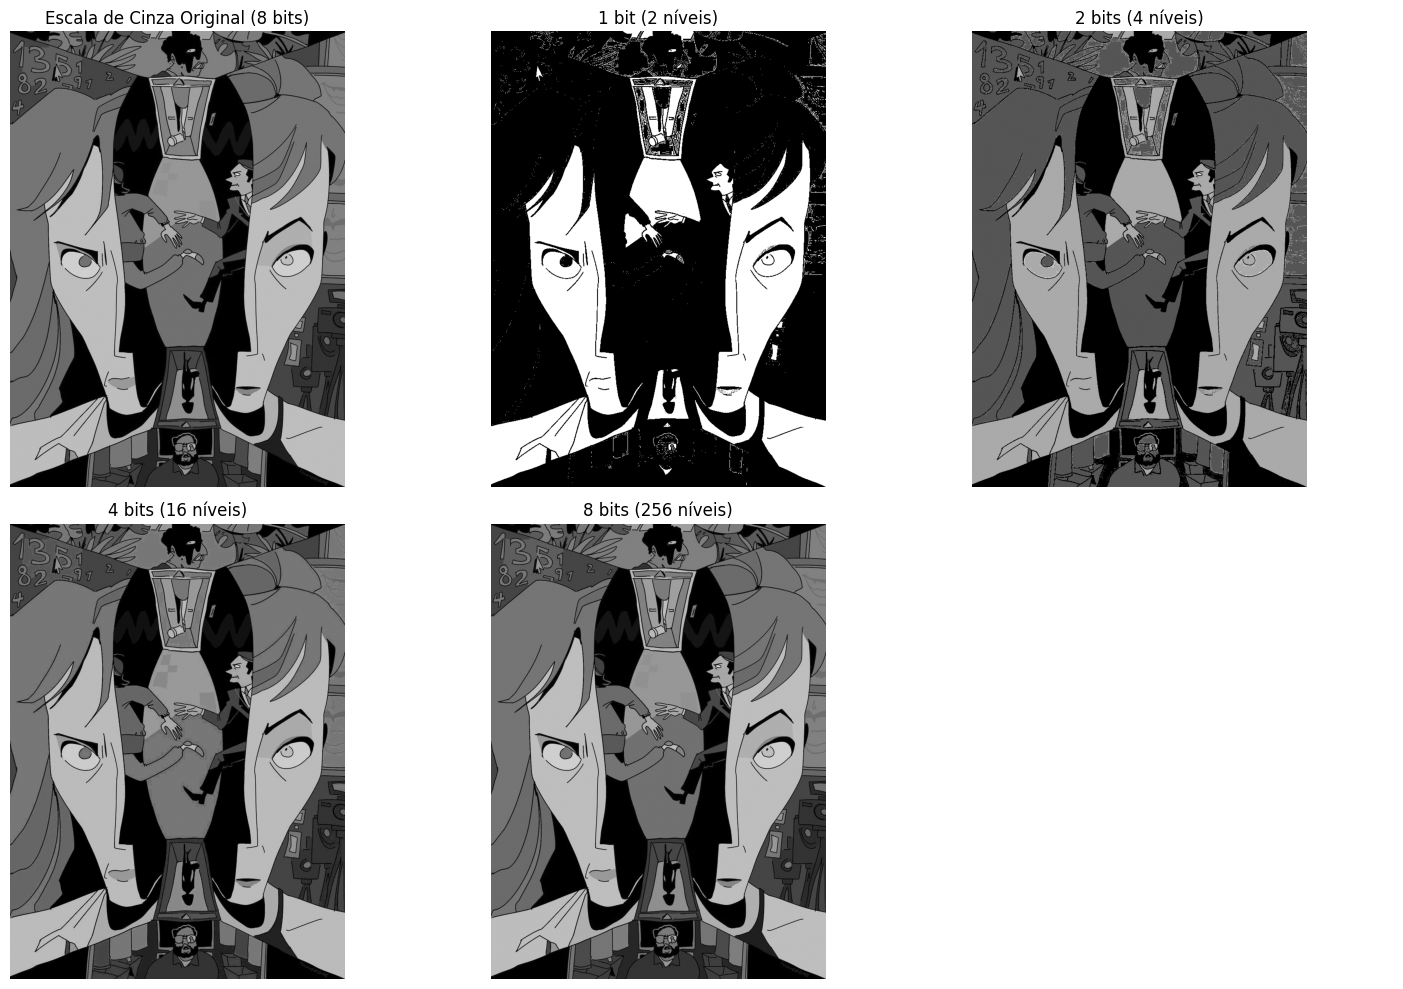

In [61]:
fig, eixos = plt.subplots(2, 3, figsize=(15, 10))
eixos = eixos.flatten()

eixos[0].imshow(img_gray_2d, cmap='gray')
eixos[0].set_title('Escala de Cinza Original (8 bits)')
eixos[0].axis('off')

eixos[1].imshow(img_1bit, cmap='gray')
eixos[1].set_title('1 bit (2 níveis)')
eixos[1].axis('off')

eixos[2].imshow(img_2bit, cmap='gray')
eixos[2].set_title('2 bits (4 níveis)')
eixos[2].axis('off')

eixos[3].imshow(img_4bit, cmap='gray')
eixos[3].set_title('4 bits (16 níveis)')
eixos[3].axis('off')

eixos[4].imshow(img_8bit, cmap='gray')
eixos[4].set_title('8 bits (256 níveis)')

eixos[4].axis('off')
eixos[5].axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png')
plt.show()

### O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?

a medida que reduzimos a quantidade de bits por pixel a imagem passa por duas alterações principais:

   **Perda de Detalhes:** As texturas e os elementos mais sutis desaparecem. Como há menos níveis de intensidade para registrar pequenas variações a imagem perde definição e ganha um aspecto mais simplificado e rústico.

   **Transições de intensidade mais bruscas:** Em vez de uma mudança gradual e natural entre o claro e o escuro, a imagem passa a ter linhas ou faixas bem marcadas dividindo as cores (efeito chamado de posterização ou banding). Isso acontece porque o computador não tem opções suficientes de cores e é forçado a juntar tons parecidos em uma única cor, estragando a passagem natural da luz e da sombra.

Em suma, diminuir a profundidade de bits compromete a fidelidade visual, transformando transições naturais em blocos rígidos de intensidade e deixando a imagem com uma aparência visivelmente "pixelada" ou artificial.